# Income Prediction and Fairness Analysis
## Using the Adult Census Income Dataset

### Author: Buhari Nasir Ahmad
### Course: Machine Learning and Its Applications

---

## 1. Introduction

The objective of this project is to build a machine learning model that predicts whether an individual earns more than $50,000 per year based on demographic and employment attributes.

This is a binary classification problem. In addition to predictive performance, the project also analyzes potential disparities in model predictions across demographic groups such as sex and race.

The dataset used is the Adult Census Income dataset derived from the 1994 U.S. Census database.

### Setting up environment

In [47]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

Python(41306) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


### Load Dataset and Initial Inspection (Raw Data)

In [20]:
import pandas as pd
# Load data
df = pd.read_csv("adult.csv")

# Exploratory Data Analysis (EDA)

This section explores the dataset to understand its structure, distributions, potential biases, and data quality issues before preprocessing and modeling.

## Preview of data

In [21]:
df.head(10)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


## Inspecting data types and non-null counts

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


## Summary Statistics

### Numerical Summary

In [23]:
print("--------------------------- Numerical Summary ---------------------------")
df.describe()

--------------------------- Numerical Summary ---------------------------


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### Categorical Summary

In [24]:
print("--------------------------- Categorical Summary ---------------------------")
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())

--------------------------- Categorical Summary ---------------------------

 workclass
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

 education
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

 marital.status
marital.status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse       

### Missing Value Analysis

In [28]:
import numpy as np
df.replace("?", np.nan, inplace=True)
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

,Missing Count,Missing Percentage
age,0,0.000000
workclass,1836,5.638647
fnlwgt,0,0.000000
education,0,0.000000
education.num,0,0.000000
marital.status,0,0.000000
occupation,1843,5.660146
relationship,0,0.000000
race,0,0.000000
sex,0,0.000000


### Target Variable Analysis Class Distribution

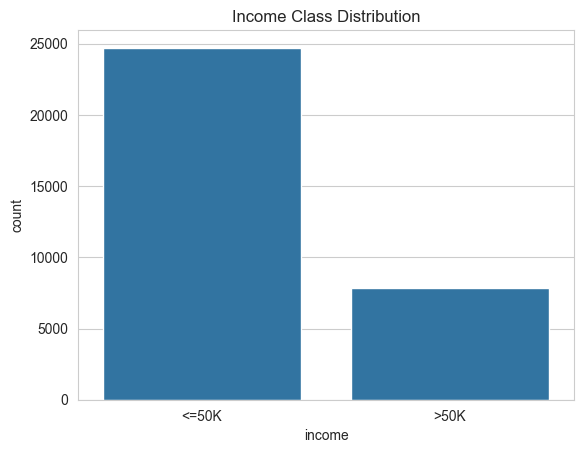

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
df['income'].value_counts()
sns.countplot(x='income', data=df)
plt.title("Income Class Distribution")
plt.show()

## Numerical Feature Distributions

### Histograms

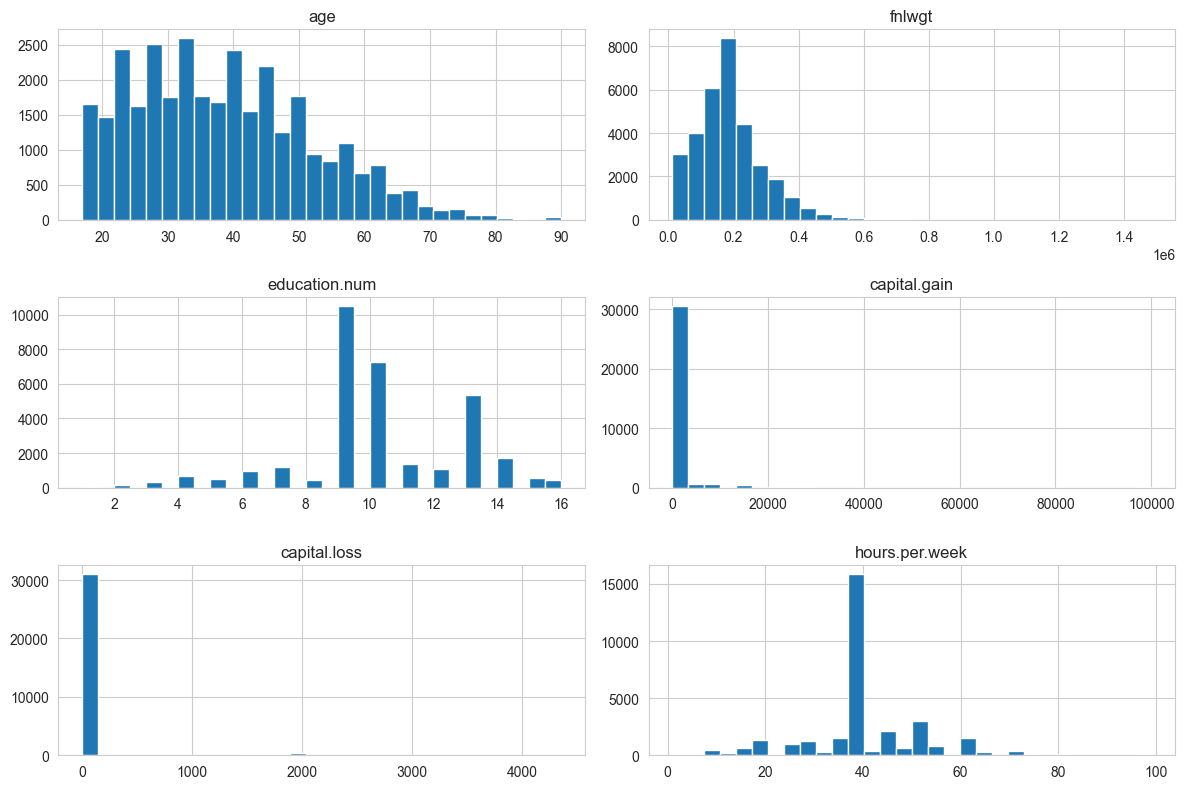

In [34]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

### Boxplots (Outlier Detection)

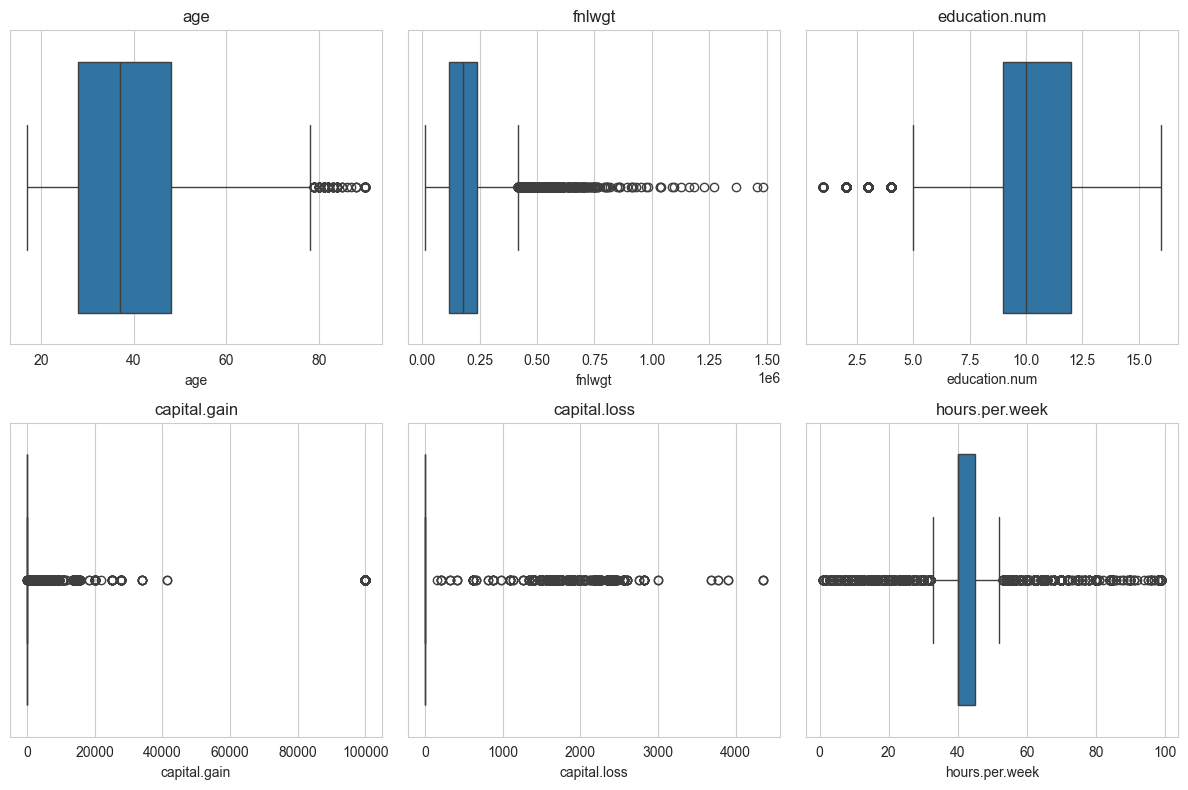

In [45]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols) + 2) // 3, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Correlation Analysis

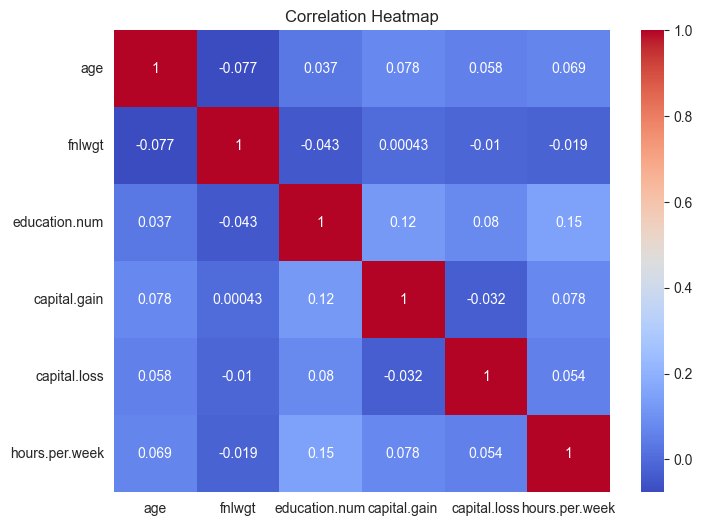

In [36]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Categorical vs Target Analysis

### Income by Sex

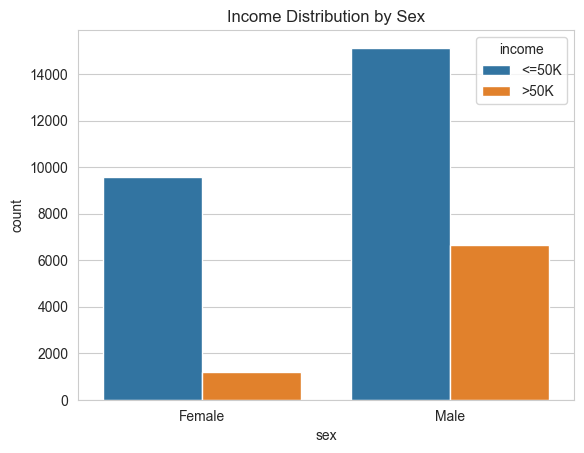

In [37]:
sns.countplot(x='sex', hue='income', data=df)
plt.title("Income Distribution by Sex")
plt.show()

### Income by Race

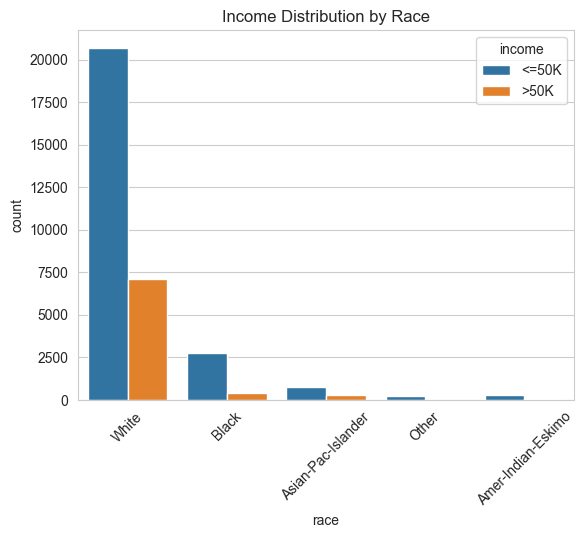

In [38]:
sns.countplot(x='race', hue='income', data=df)
plt.xticks(rotation=45)
plt.title("Income Distribution by Race")
plt.show()

### Income by Education

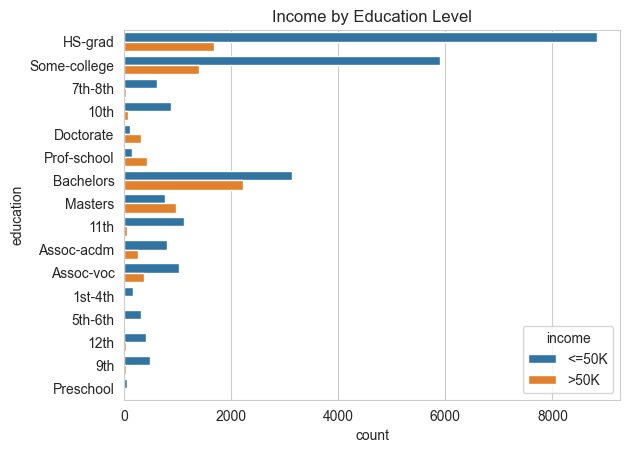

In [46]:
sns.countplot(y='education', hue='income', data=df)
plt.title("Income by Education Level")
plt.show()

### Numerical Features vs Target

### Age vs Income

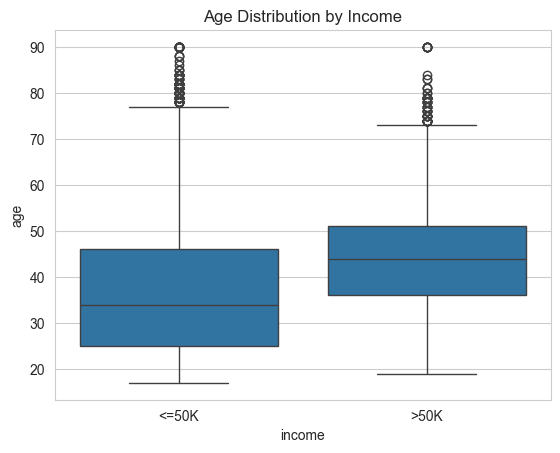

In [40]:
sns.boxplot(x='income', y='age', data=df)
plt.title("Age Distribution by Income")
plt.show()

### Hours per Week vs Income

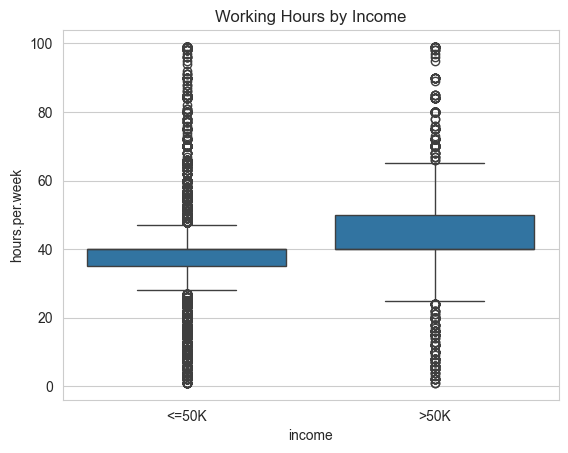

In [42]:
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.title("Working Hours by Income")
plt.show()

### Bias-Focused Statistical View

In [43]:
pd.crosstab(df['sex'], df['income'], normalize='index') * 100

income,<=50K,>50K
sex,,
Female,89.053941,10.946059
Male,69.426342,30.573658


In [44]:
pd.crosstab(df['race'], df['income'], normalize='index') * 100

income,<=50K,>50K
race,,
Amer-Indian-Eskimo,88.424437,11.575563
Asian-Pac-Islander,73.435996,26.564004
Black,87.612036,12.387964
Other,90.774908,9.225092
White,74.414006,25.585994
